1.Generate data and train the model

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.linalg import sqrtm

# ==============================
# [0] Global parameters
# ==============================
d = 3               # state dimension
m = 1               # control dimension
Nt = 100            # number of time steps
r_base = 5          # number of basis functions
T_end = 1.0         # time normalized to [0,1]
N_traj = 1000        # number of trajectories
batch_size = 32
lr = 1e-3
train_epochs = 60
alpha = 1e-6        # positive definite threshold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# [1] Basis functions: phi_i(t) = cos(iπt)
# ==============================
def phi(i, t):
    if i == 0:
        return 1.0
    if i % 2 == 1:          # cos
        k = (i + 1) // 2
        return np.cos(k * np.pi * t)
    else:                   # sin
        k = i // 2
        return np.sin(k * np.pi * t)
# ==============================
# [2] Generate one trajectory (with controllability/observability/positive definiteness screening)
# ==============================
def generate_one_valid_trajectory(max_trial=100):
    """
    Generate a trajectory that satisfies conditions.
    Returns list of dicts with keys: 'C','D','E','P_T','R','t','P','A','B'
    Time order: increasing from 0 to T_end (inclusive).
    """
    for _ in range(max_trial):
        C = [np.random.randn(d, d)*0.05 for _ in range(r_base)]
        D = [np.random.randn(d, m)*0.05 for _ in range(r_base)]
        E = [np.random.randn(d, d)*0.05 for _ in range(r_base)]

        R = np.eye(m)
        R_inv = np.linalg.inv(R)
        P_T = np.eye(d)

        def A(t):
            return sum((C[i]*phi(i, t) for i in range(r_base)), start=np.zeros((d,d)))
        def B(t):
            return sum((D[i]*phi(i, t) for i in range(r_base)), start=np.zeros((d,m)))
        def Q(t):
            M = sum((E[i]*phi(i, t) for i in range(r_base)), start=np.zeros((d,d)))
            return M @ M.T

        t_seq = np.linspace(0, T_end, Nt)
        dt = t_seq[1] - t_seq[0]
        h = -dt

        def riccati_rhs(t, P):
            return -A(t).T @ P - P @ A(t) + P @ B(t) @ R_inv @ B(t).T @ P - Q(t)

        # 1. 先存储终端条件
        traj_data = [{
            'C': C, 'D': D, 'E': E,
            'P_T': P_T, 'R': R,
            't': t_seq[-1],
            'P': P_T.copy(),
            'A': A(t_seq[-1]),
            'B': B(t_seq[-1])
        }]

        P = P_T.copy()
        valid = True

        # 2. 反向积分，从倒数第二个点开始到第一个点
        for idx in range(Nt-2, -1, -1):
            tk = t_seq[idx]          # 目标时间
            # 当前 P 对应 t = t_seq[idx+1]，向后积分一步
            k1 = riccati_rhs(tk + dt, P)
            t_mid = tk + dt + h/2
            P_mid = P + h/2 * k1
            k2 = riccati_rhs(t_mid, P_mid)
            P_mid2 = P + h/2 * k2
            k3 = riccati_rhs(t_mid, P_mid2)
            t_next = tk + dt + h      # = tk
            P_end = P + h * k3
            k4 = riccati_rhs(t_next, P_end)
            Pk = P + h/6 * (k1 + 2*k2 + 2*k3 + k4)
            Pk = (Pk + Pk.T) / 2

            # 筛选条件（不变）
            K = R_inv @ B(tk).T @ Pk
            if np.min(np.linalg.eigvals(Q(tk) + K.T @ R @ K)) < alpha:
                valid = False
                break

            # 可控性
            C_mat = B(tk)
            for i in range(1, d):
                C_mat = np.hstack((C_mat, np.linalg.matrix_power(A(tk), i) @ B(tk)))
            if np.linalg.matrix_rank(C_mat) < d:
                valid = False
                break

            # 可观性
            Q_sqrt = sqrtm(Q(tk)).real
            O_mat = Q_sqrt
            for i in range(1, d):
                O_mat = np.vstack((O_mat, Q_sqrt @ np.linalg.matrix_power(A(tk), i)))
            if np.linalg.matrix_rank(O_mat) < d:
                valid = False
                break

            traj_data.append({
                'C': C, 'D': D, 'E': E,
                'P_T': P_T, 'R': R,
                't': tk,
                'P': Pk,
                'A': A(tk),
                'B': B(tk)
            })
            P = Pk

        if valid:
            traj_data.reverse()   # 时间递增：0 → T
            return traj_data

    return None

# ==============================
# [3] Build dataset (only collect time-point samples from valid trajectories)
# ==============================
def build_dataset(N_traj):
    all_data = []
    traj_count = 0
    attempts = 0

    while traj_count < N_traj:
        traj = generate_one_valid_trajectory()
        attempts += 1
        if traj is not None:
            all_data.extend(traj)
            traj_count += 1

        if attempts % 100 == 0:
            print(f"Attempts {attempts}, successful trajectories {traj_count}")

    print(f"Final generated {traj_count} trajectories")
    return all_data

print("Start generating dataset...")
dataset = build_dataset(N_traj)
print(f"Dataset generation completed, total samples: {len(dataset)}")

# ==============================
# [4] Flatten basis coefficients
# ==============================
def flatten_coeffs(C, D, E, P_T):
    c_vec = [ci.flatten() for ci in C]
    d_vec = [di.flatten() for di in D]
    e_vec = [ei.flatten() for ei in E]
    pT_vec = P_T.flatten()
    return np.concatenate(c_vec + d_vec + e_vec + [pT_vec])

# ==============================
# [5] Dataset
# ==============================
class RiccatiCoeffDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        dct = self.data[idx]
        branch = flatten_coeffs(dct['C'], dct['D'], dct['E'], dct['P_T'])
        trunk = np.array([dct['t']])
        label = dct['P'].flatten()
        return (torch.FloatTensor(branch),
                torch.FloatTensor(trunk),
                torch.FloatTensor(label))

dset = RiccatiCoeffDataset(dataset)
loader = DataLoader(dset, batch_size=batch_size, shuffle=True)

# ==============================
# [6] Automatically compute dimensions
# ==============================
# C: r_base*d*d, D: r_base*d*m, E: r_base*d*d, P_T: d*d
branch_dim = r_base*d*d + r_base*d*m + r_base*d*d + d*d
out_dim = d*d
print("="*60)
print(f"Dimension info: branch_dim = {branch_dim}, out_dim = {out_dim}")
print(f"Total number of P matrix elements: {d*d} ({d}×{d})")
print("="*60)

# ==============================
# [7] DeepONet model + GPU transfer
# ==============================
class DeepONet(nn.Module):
    def __init__(self, branch_dim, out_dim, p=128):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(branch_dim, 256), nn.GELU(),
            nn.Linear(256, 256), nn.GELU(),
            nn.Linear(256, p)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, 128), nn.GELU(),
            nn.Linear(128, 128), nn.GELU(),
            nn.Linear(128, p)
        )
        self.fc = nn.Linear(p, out_dim)

    def forward(self, b_in, t_in):
        b = self.branch(b_in)
        t = self.trunk(t_in)
        return self.fc(b * t)

model = DeepONet(branch_dim, out_dim).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Print dimensions of first batch
for branch, trunk, y in loader:
    branch = branch.to(device)
    trunk = trunk.to(device)
    y = y.to(device)
    print("First batch dimensions:")
    print(f"branch: {branch.shape}, trunk: {trunk.shape}, label: {y.shape}")
    break

# ==============================
# [8] Training
# ==============================
print("\nStart calculating initial loss (model not trained)...")
model.eval()
init_total_loss = 0.0
with torch.no_grad():
    for b, t, y in loader:
        b = b.to(device)
        t = t.to(device)
        y = y.to(device)
        y_hat = model(b, t)
        loss = loss_fn(y_hat, y)
        init_total_loss += loss.item()
init_avg_loss = init_total_loss / len(loader)

print("="*60)
print(f"Epoch  0 | Initial loss (untrained): {init_avg_loss:.6f}")
print("="*60)

print("\nStart formal training...")
start_time = time.time()
model.train()
for epoch in range(1, train_epochs + 1):
    total_loss = 0.0
    for b, t, y in loader:
        b = b.to(device)
        t = t.to(device)
        y = y.to(device)
        opt.zero_grad()
        y_hat = model(b, t)
        loss = loss_fn(y_hat, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Avg Loss {avg_loss:.8f}")

end_time = time.time()
train_total_time = end_time - start_time
train_hours = int(train_total_time // 3600)
train_minutes = int((train_total_time % 3600) // 60)
train_seconds = train_total_time % 60

print("\n" + "="*60)
print(f"Training completed! Total time: {train_hours} hours {train_minutes} minutes {train_seconds:.2f} seconds")
print(f"Total training seconds: {train_total_time:.2f}s")
print("="*60)

save_dir = os.path.join(os.getcwd(), "DRE_3D_cs")
os.makedirs(save_dir, exist_ok=True)
model_save_name = f"DeepONet_model_d{d}_epochs{train_epochs}.pth"
model_save_path = os.path.join(save_dir, model_save_name)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': opt.state_dict(),
    'train_epochs': train_epochs,
    'lr': lr,
    'final_loss': avg_loss
}, model_save_path)
print(f"Model saved to: {model_save_path}")

Start generating dataset...
Attempts 100, successful trajectories 100
Attempts 200, successful trajectories 200
Attempts 300, successful trajectories 300
Attempts 400, successful trajectories 400
Attempts 500, successful trajectories 500
Attempts 600, successful trajectories 600
Attempts 700, successful trajectories 700
Attempts 800, successful trajectories 800
Attempts 900, successful trajectories 900
Attempts 1000, successful trajectories 1000
Final generated 1000 trajectories
Dataset generation completed, total samples: 100000
Dimension info: branch_dim = 114, out_dim = 9
Total number of P matrix elements: 9 (3×3)
First batch dimensions:
branch: torch.Size([32, 114]), trunk: torch.Size([32, 1]), label: torch.Size([32, 9])

Start calculating initial loss (model not trained)...
Epoch  0 | Initial loss (untrained): 0.382538

Start formal training...
Epoch  5 | Avg Loss 0.00006328
Epoch 10 | Avg Loss 0.00002233
Epoch 15 | Avg Loss 0.00001301
Epoch 20 | Avg Loss 0.00000937
Epoch 25 | Avg

2.Calculation error and drawing

Model loaded successfully: DRE_3D_cs/DeepONet_model_d3_epochs60.pth
Start generating 100 test trajectories...
Attempts 100, valid trajectories so far 100
Test set generation completed: 100 trajectories
Processed 20/100 trajectories
Processed 40/100 trajectories
Processed 60/100 trajectories
Processed 80/100 trajectories
Processed 100/100 trajectories

========== Test Results ==========
e_P  (absolute) = 0.029209018
e_P^r (relative) = 0.016615479
e_x  (absolute) = 0.000159687
e_x^r (relative) = 0.000106256
e_J  (absolute) = 0.000009265
e_J^r (relative) = 0.000002909

Plotting comparison for the first test trajectory...


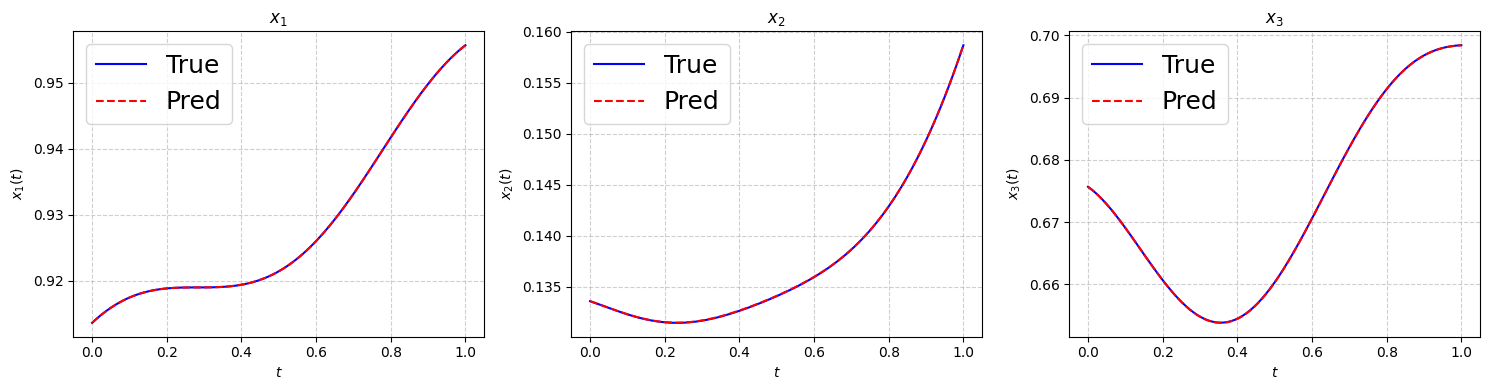

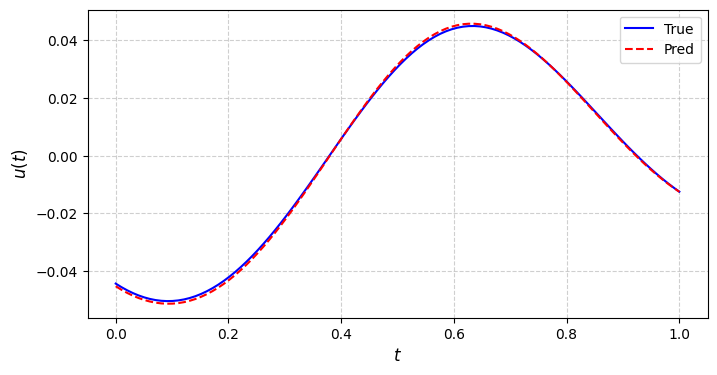

All results saved to DRE_3D_cs folder
Plot data saved to DRE_3D_cs\plot_data.npz


In [8]:
import os
import numpy as np
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.linalg import sqrtm
from scipy.integrate import trapezoid

np.random.seed(42)
torch.manual_seed(42)

# ==============================
# Global parameters (must be consistent with training)
# ==============================
d = 3               # state dimension
m = 1               # control dimension
Nt = 100            # number of time steps
r_base = 5          # number of basis functions
T_end = 1.0         # time interval
alpha = 1e-6        # positive definite threshold
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# Model definition (must have same structure as training)
# ==============================
class DeepONet(nn.Module):
    def __init__(self, branch_dim, out_dim, p=128):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(branch_dim, 256), nn.GELU(),
            nn.Linear(256, 256), nn.GELU(),
            nn.Linear(256, p)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, 128), nn.GELU(),
            nn.Linear(128, 128), nn.GELU(),
            nn.Linear(128, p)
        )
        self.fc = nn.Linear(p, out_dim)

    def forward(self, b_in, t_in):
        b = self.branch(b_in)
        t = self.trunk(t_in)
        return self.fc(b * t)

# ==============================
# Basis functions
# ==============================
def phi(i, t):
    if i == 0:
        return 1.0
    if i % 2 == 1:          # cos
        k = (i + 1) // 2
        return np.cos(k * np.pi * t)
    else:                   # sin
        k = i // 2
        return np.sin(k * np.pi * t)

# ==============================
# Flatten basis coefficients (same as training)
# ==============================
def flatten_coeffs(C, D, E, P_T):
    c_vec = [ci.flatten() for ci in C]
    d_vec = [di.flatten() for di in D]
    e_vec = [ei.flatten() for ei in E]
    pT_vec = P_T.flatten()
    return np.concatenate(c_vec + d_vec + e_vec + [pT_vec])

# ==============================
# Generate a valid test trajectory (same as training)
# ==============================
def generate_one_valid_trajectory(max_trial=100):
    """
    Generate a trajectory that satisfies conditions.
    Returns list of dicts with keys: 'C','D','E','P_T','R','t','P','A','B'
    Time order: increasing from 0 to T_end (inclusive).
    """
    for _ in range(max_trial):
        C = [np.random.randn(d, d)*0.05 for _ in range(r_base)]
        D = [np.random.randn(d, m)*0.05 for _ in range(r_base)]
        E = [np.random.randn(d, d)*0.05 for _ in range(r_base)]

        R = np.eye(m)
        R_inv = np.linalg.inv(R)
        P_T = np.eye(d)

        def A(t):
            return sum((C[i]*phi(i, t) for i in range(r_base)), start=np.zeros((d,d)))
        def B(t):
            return sum((D[i]*phi(i, t) for i in range(r_base)), start=np.zeros((d,m)))
        def Q(t):
            M = sum((E[i]*phi(i, t) for i in range(r_base)), start=np.zeros((d,d)))
            return M @ M.T

        t_seq = np.linspace(0, T_end, Nt)
        dt = t_seq[1] - t_seq[0]
        h = -dt

        def riccati_rhs(t, P):
            return -A(t).T @ P - P @ A(t) + P @ B(t) @ R_inv @ B(t).T @ P - Q(t)

        # 1. 先存储终端条件
        traj_data = [{
            'C': C, 'D': D, 'E': E,
            'P_T': P_T, 'R': R,
            't': t_seq[-1],
            'P': P_T.copy(),
            'A': A(t_seq[-1]),
            'B': B(t_seq[-1])
        }]

        P = P_T.copy()
        valid = True

        # 2. 反向积分，从倒数第二个点开始到第一个点
        for idx in range(Nt-2, -1, -1):
            tk = t_seq[idx]          # 目标时间
            # 当前 P 对应 t = t_seq[idx+1]，向后积分一步
            k1 = riccati_rhs(tk + dt, P)
            t_mid = tk + dt + h/2
            P_mid = P + h/2 * k1
            k2 = riccati_rhs(t_mid, P_mid)
            P_mid2 = P + h/2 * k2
            k3 = riccati_rhs(t_mid, P_mid2)
            t_next = tk + dt + h      # = tk
            P_end = P + h * k3
            k4 = riccati_rhs(t_next, P_end)
            Pk = P + h/6 * (k1 + 2*k2 + 2*k3 + k4)
            Pk = (Pk + Pk.T) / 2

            # 筛选条件（不变）
            K = R_inv @ B(tk).T @ Pk
            if np.min(np.linalg.eigvals(Q(tk) + K.T @ R @ K)) < alpha:
                valid = False
                break

            # 可控性
            C_mat = B(tk)
            for i in range(1, d):
                C_mat = np.hstack((C_mat, np.linalg.matrix_power(A(tk), i) @ B(tk)))
            if np.linalg.matrix_rank(C_mat) < d:
                valid = False
                break

            # 可观性
            Q_sqrt = sqrtm(Q(tk)).real
            O_mat = Q_sqrt
            for i in range(1, d):
                O_mat = np.vstack((O_mat, Q_sqrt @ np.linalg.matrix_power(A(tk), i)))
            if np.linalg.matrix_rank(O_mat) < d:
                valid = False
                break

            traj_data.append({
                'C': C, 'D': D, 'E': E,
                'P_T': P_T, 'R': R,
                't': tk,
                'P': Pk,
                'A': A(tk),
                'B': B(tk)
            })
            P = Pk

        if valid:
            traj_data.reverse()   # 时间递增：0 → T
            return traj_data

    return None

# ==============================
# State simulation (RK4)
# ==============================
def simulate_state_rk4(t_seq, A_list, B_list, P_list, R, x0):
    """
    Integrate closed-loop system dx/dt = (A - B R^{-1} B^T P) x using RK4
    """
    Nt = len(t_seq)
    dt = t_seq[1] - t_seq[0]
    x = x0.copy()
    x_traj = [x.copy()]
    R_inv = np.linalg.inv(R)

    for k in range(Nt-1):
        A = A_list[k]
        B = B_list[k]
        P = P_list[k]
        K = R_inv @ B.T @ P
        A_cl = A - B @ K

        # RK4 steps
        k1 = A_cl @ x
        k2 = A_cl @ (x + 0.5 * dt * k1)
        k3 = A_cl @ (x + 0.5 * dt * k2)
        k4 = A_cl @ (x + dt * k3)
        x = x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
        x_traj.append(x.copy())

    return np.array(x_traj)

# ==============================
# Main program
# ==============================
if __name__ == "__main__":
    # ------------------------------
    # 1. Load model
    # ------------------------------
    model_path = "DRE_3D_cs/DeepONet_model_d3_epochs60.pth"  # modify to actual path
    save_dir = "DRE_3D_cs"
    os.makedirs(save_dir, exist_ok=True)

    # Compute dimensions (same as training)
    branch_dim = r_base*d*d + r_base*d*m + r_base*d*d + d*d
    out_dim = d*d

    model = DeepONet(branch_dim, out_dim).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Model loaded successfully: {model_path}")

    # ------------------------------
    # 2. Generate test trajectories
    # ------------------------------
    M_test = 100
    print(f"Start generating {M_test} test trajectories...")
    test_trajectories = []
    attempts = 0
    while len(test_trajectories) < M_test:
        traj = generate_one_valid_trajectory()
        attempts += 1
        if traj is not None:
            test_trajectories.append(traj)
        if attempts % 100 == 0:
            print(f"Attempts {attempts}, valid trajectories so far {len(test_trajectories)}")
    print(f"Test set generation completed: {len(test_trajectories)} trajectories")

    # ------------------------------
    # 3. Error calculation
    # ------------------------------
    e_P_list = []
    e_Pr_list = []
    e_x_list = []
    e_xr_list = []
    e_J_list = []
    e_Jr_list = []

    for idx, traj in enumerate(test_trajectories):
        # Extract basic information
        t_seq = np.array([s['t'] for s in traj])
        Nt_actual = len(t_seq)
        C = traj[0]['C']
        D = traj[0]['D']
        E = traj[0]['E']
        P_T = traj[0]['P_T']
        R = traj[0]['R']
        R_inv = np.linalg.inv(R)

        # Build A, B, Q, P_true lists
        A_list = []
        B_list = []
        Q_list = []
        P_true_list = []
        for s in traj:
            A_list.append(s['A'])
            B_list.append(s['B'])
            # Compute Q(t)
            M = sum((E[i]*phi(i, s['t']) for i in range(r_base)), start=np.zeros((d,d)))
            Q = M @ M.T
            Q_list.append(Q)
            P_true_list.append(s['P'])
        A_list = np.array(A_list)
        B_list = np.array(B_list)
        Q_list = np.array(Q_list)
        P_true_list = np.array(P_true_list)

        # Model prediction for P
        branch_vec = flatten_coeffs(C, D, E, P_T)
        branch_tensor = torch.FloatTensor(branch_vec).to(device)
        trunk_tensor = torch.FloatTensor(t_seq[:, None]).to(device)
        with torch.no_grad():
            P_pred_tensor = model(branch_tensor.repeat(Nt_actual, 1), trunk_tensor)
        P_pred_list = P_pred_tensor.cpu().numpy().reshape(Nt_actual, d, d)

        # Random initial state (different x0 for different trajectories)
        x0 = np.random.randn(d)

        # True state trajectory
        x_true = simulate_state_rk4(t_seq, A_list, B_list, P_true_list, R, x0)
        # Predicted state trajectory
        x_pred = simulate_state_rk4(t_seq, A_list, B_list, P_pred_list, R, x0)

        # Compute control inputs (for cost)
        u_true = np.zeros((Nt_actual, m))
        u_pred = np.zeros((Nt_actual, m))
        for k in range(Nt_actual):
            K_true = R_inv @ B_list[k].T @ P_true_list[k]
            K_pred = R_inv @ B_list[k].T @ P_pred_list[k]
            u_true[k] = -K_true @ x_true[k]
            u_pred[k] = -K_pred @ x_pred[k]

        # Compute cost (trapezoidal integration)
        dt = t_seq[1] - t_seq[0]
        J_true = 0.0
        J_pred = 0.0
        for k in range(Nt_actual):
            integ_true = x_true[k] @ Q_list[k] @ x_true[k] + u_true[k] @ R @ u_true[k]
            integ_pred = x_pred[k] @ Q_list[k] @ x_pred[k] + u_pred[k] @ R @ u_pred[k]
            if k == 0 or k == Nt_actual-1:
                J_true += 0.5 * integ_true * dt
                J_pred += 0.5 * integ_pred * dt
            else:
                J_true += integ_true * dt
                J_pred += integ_pred * dt
        # Terminal term
        J_true += x_true[-1] @ P_T @ x_true[-1]
        J_pred += x_pred[-1] @ P_T @ x_pred[-1]

        # P error
        P_err_sq = np.sum((P_true_list - P_pred_list)**2, axis=(1,2))
        P_int_err = np.sqrt(np.trapezoid(P_err_sq, t_seq))
        P_int_true = np.sqrt(np.trapezoid(np.sum(P_true_list**2, axis=(1,2)), t_seq))
        e_P_list.append(P_int_err)
        e_Pr_list.append(P_int_err / P_int_true if P_int_true > 0 else 0.0)

        # State error
        x_err_sq = np.sum((x_true - x_pred)**2, axis=1)
        x_int_err = np.sqrt(np.trapezoid(x_err_sq, t_seq))
        x_int_true = np.sqrt(np.trapezoid(np.sum(x_true**2, axis=1), t_seq))
        e_x_list.append(x_int_err)
        e_xr_list.append(x_int_err / x_int_true if x_int_true > 0 else 0.0)

        # Cost error
        e_J_list.append(abs(J_true - J_pred))
        e_Jr_list.append(abs(J_true - J_pred) / abs(J_true) if abs(J_true) > 0 else 0.0)

        # Optional: print progress
        if (idx+1) % 20 == 0:
            print(f"Processed {idx+1}/{M_test} trajectories")

    # Average errors
    e_P_avg = np.mean(e_P_list)
    e_Pr_avg = np.mean(e_Pr_list)
    e_x_avg = np.mean(e_x_list)
    e_xr_avg = np.mean(e_xr_list)
    e_J_avg = np.mean(e_J_list)
    e_Jr_avg = np.mean(e_Jr_list)

    print("\n========== Test Results ==========")
    print(f"e_P  (absolute) = {e_P_avg:.9f}")
    print(f"e_P^r (relative) = {e_Pr_avg:.9f}")
    print(f"e_x  (absolute) = {e_x_avg:.9f}")
    print(f"e_x^r (relative) = {e_xr_avg:.9f}")
    print(f"e_J  (absolute) = {e_J_avg:.9f}")
    print(f"e_J^r (relative) = {e_Jr_avg:.9f}")
    print("==================================\n")

    # ------------------------------
    # 4. Plot comparison for the first trajectory
    # ------------------------------
    print("Plotting comparison for the first test trajectory...")
    traj0 = test_trajectories[0]
    t_seq0 = np.array([s['t'] for s in traj0])
    Nt0 = len(t_seq0)
    C0, D0, E0 = traj0[0]['C'], traj0[0]['D'], traj0[0]['E']
    P_T0 = traj0[0]['P_T']
    R0 = traj0[0]['R']
    R_inv0 = np.linalg.inv(R0)

    # Compute true and predicted P
    P_true0 = np.array([s['P'] for s in traj0])
    branch_vec0 = flatten_coeffs(C0, D0, E0, P_T0)
    branch_tensor0 = torch.FloatTensor(branch_vec0).to(device)
    trunk_tensor0 = torch.FloatTensor(t_seq0[:, None]).to(device)
    with torch.no_grad():
        P_pred0_tensor = model(branch_tensor0.repeat(Nt0, 1), trunk_tensor0)
    P_pred0 = P_pred0_tensor.cpu().numpy().reshape(Nt0, d, d)

    # Recompute A, B, Q lists (note traj0 already has A,B, but need to recompute Q)
    A0 = np.array([s['A'] for s in traj0])
    B0 = np.array([s['B'] for s in traj0])
    Q0_list = []
    for s in traj0:
        M = sum((E0[i]*phi(i, s['t']) for i in range(r_base)), start=np.zeros((d,d)))
        Q0_list.append(M @ M.T)
    Q0_list = np.array(Q0_list)

    # Fixed initial state (set seed for reproducibility)
    # np.random.seed(42)
    x0_plot = np.random.randn(d)

    # State simulation
    x_true0 = simulate_state_rk4(t_seq0, A0, B0, P_true0, R0, x0_plot)
    x_pred0 = simulate_state_rk4(t_seq0, A0, B0, P_pred0, R0, x0_plot)


    # Control inputs
    u_true0 = np.zeros((Nt0, m))
    u_pred0 = np.zeros((Nt0, m))
    for k in range(Nt0):
        K_true = R_inv0 @ B0[k].T @ P_true0[k]
        K_pred = R_inv0 @ B0[k].T @ P_pred0[k]
        u_true0[k] = -K_true @ x_true0[k]
        u_pred0[k] = -K_pred @ x_pred0[k]

    # State comparison plot
    fig, axes = plt.subplots(1, d, figsize=(5*d, 4))
    for i in range(d):
        axes[i].plot(t_seq0, x_true0[:, i], 'b-', label='True', linewidth=1.5)
        axes[i].plot(t_seq0, x_pred0[:, i], 'r--', label='Pred', linewidth=1.5)
        axes[i].set_title(f'$x_{i+1}$', fontsize=12)
        axes[i].set_xlabel('$t$', fontsize=10)
        axes[i].set_ylabel(f'$x_{i+1}(t)$', fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.6)
        axes[i].legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "state_comparison.png"), dpi=150)
    plt.show()

    # Control comparison plot
    plt.figure(figsize=(8,4))
    plt.plot(t_seq0, u_true0, 'b-', label='True', linewidth=1.5)
    plt.plot(t_seq0, u_pred0, 'r--', label='Pred', linewidth=1.5)
    plt.xlabel('$t$', fontsize=12)
    plt.ylabel('$u(t)$', fontsize=12)
    #plt.title('Control Input Comparison', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "control_comparison.png"), dpi=150)
    plt.show()
    print(f"All results saved to {save_dir} folder")

    # ------------------------------
    # 5. Save plotting data for the first trajectory (optional)
    # ------------------------------
    plot_data = {
        't_seq': t_seq0,
        'x_true': x_true0,
        'x_pred': x_pred0,
        'u_true': u_true0,
        'u_pred': u_pred0,
        # 'P_true': P_true0,
        # 'P_pred': P_pred0,
    }
    save_path = os.path.join(save_dir, "plot_data.npz")
    np.savez(save_path, **plot_data)
    print(f"Plot data saved to {save_path}")

3.Draw picture

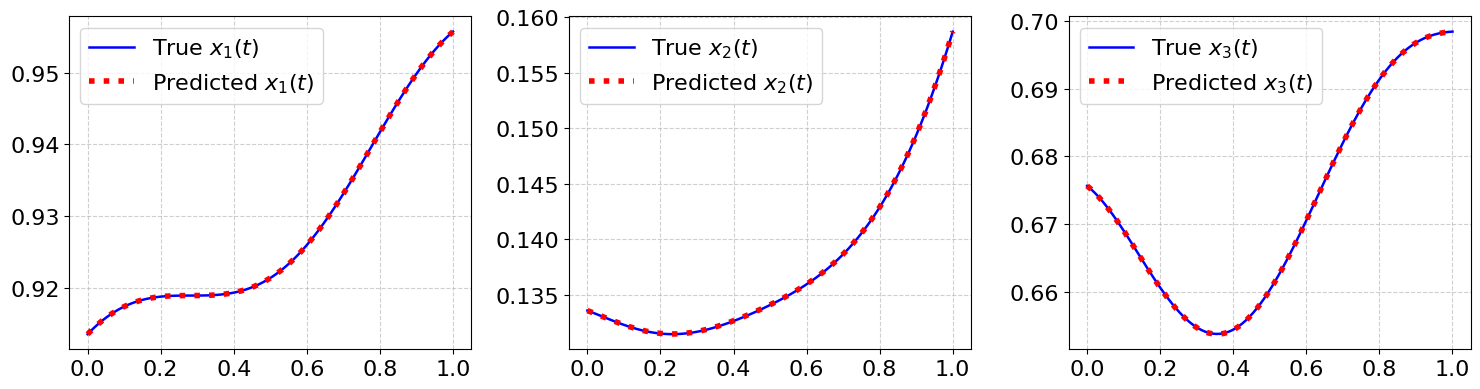

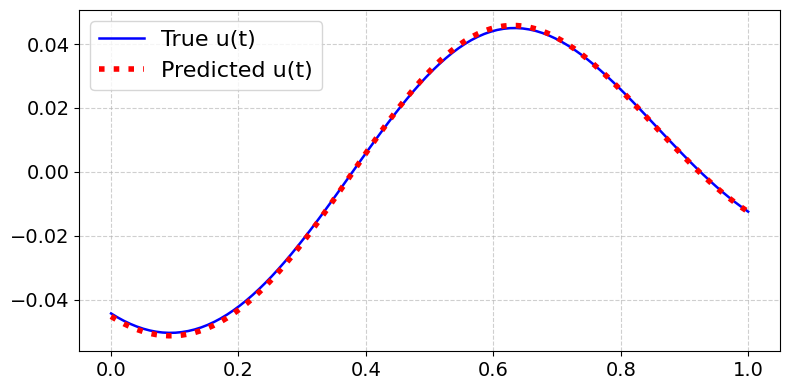

Plots saved to DRE_3D_cs


In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# User-modifiable plotting parameters
# ==============================
SAVE_DIR = "DRE_3D_cs"                 # Same directory used when saving data
DATA_FILE = "plot_data.npz"            # Name of the saved data file
OUTPUT_STATE_PLOT = "state_comparison.png"   # Output filename for state plot
OUTPUT_CONTROL_PLOT = "control_comparison.png" # Output filename for control plot

# Plot style customization
STATE_LINEWIDTH = 3.8      # Line width for state trajectories
CONTROL_LINEWIDTH = 1.8    # Line width for control input
FONTSIZE_LABEL = 20        # Font size for axis labels
FONTSIZE_TITLE = 20        # Font size for subplot titles
FONTSIZE_LEGEND = 16       # Font size for legend
GRID_ALPHA = 0.6           # Transparency of grid lines
GRID_LINESTYLE = '--'      # Line style for grid

# ==============================
# Load data
# ==============================
# Construct full path to the data file
data_path = os.path.join(SAVE_DIR, DATA_FILE)
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found: {data_path}")

# Load the saved numpy archive
data = np.load(data_path)
t_seq = data['t_seq']      # Time points (1D array)
x_true = data['x_true']    # True state trajectories (Nt x d)
x_pred = data['x_pred']    # Predicted state trajectories (Nt x d)
u_true = data['u_true']    # True control inputs (Nt x m)
u_pred = data['u_pred']    # Predicted control inputs (Nt x m)

# Get state dimension (d = number of state variables)
d = x_true.shape[1]

# ==============================
# Plot state component comparison
# ==============================
# Create a figure with 1 row and d columns of subplots
fig, axes = plt.subplots(1, d, figsize=(5*d, 4))
if d == 1:
    axes = [axes]

for i in range(d):
    ax = axes[i]
    
    ax.plot(t_seq, x_true[:, i], 'b-', label=rf'True $x_{{{i+1}}}(t)$', linewidth=1.8)
    ax.plot(t_seq, x_pred[:, i], 'r:', label=rf'Predicted $x_{{{i+1}}}(t)$', linewidth=4)
    
    #ax.set_title(rf'$x_{{{i+1}}}$', fontsize=FONTSIZE_TITLE)
    #ax.set_xlabel('$t$', fontsize=FONTSIZE_LABEL)
    #ax.set_ylabel(rf'$x_{{{i+1}}}(t)$', fontsize=FONTSIZE_LABEL)
    
    ax.tick_params(axis='x', labelsize=16, rotation=0)
    ax.tick_params(axis='y', labelsize=16, rotation=0)
    
    ax.grid(True, linestyle=GRID_LINESTYLE, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONTSIZE_LEGEND)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, OUTPUT_STATE_PLOT), dpi=150)
plt.show()

# ==============================
# Plot control input comparison
# ==============================
# Create a new figure for control input (single plot)
plt.figure(figsize=(8,4))
plt.plot(t_seq, u_true, 'b-', label='True u(t)', linewidth=1.8)
plt.plot(t_seq, u_pred, 'r:', label='Predicted u(t)', linewidth=4)
#plt.xlabel('$t$', fontsize=FONTSIZE_LABEL)
#plt.ylabel('$u(t)$', fontsize=FONTSIZE_LABEL)
plt.grid(True, linestyle=GRID_LINESTYLE, alpha=GRID_ALPHA)
plt.legend(fontsize=FONTSIZE_LEGEND, loc='upper left')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, OUTPUT_CONTROL_PLOT), dpi=150)
plt.show()

# Print confirmation message
print(f"Plots saved to {SAVE_DIR}")

4.Time

Using device: cuda
Model loaded successfully: DRE_3D/DeepONet_model_d3_epochs50.pth
Generating 100 fixed random systems...

Testing Nt = 50 ...
  Performing RK4 test...
    RK4 completed 20/100 samples
    RK4 completed 40/100 samples
    RK4 completed 60/100 samples
    RK4 completed 80/100 samples
    RK4 completed 100/100 samples
    RK4 average time: 11.1564 ms
  Performing DeepONet batch test...
    DeepONet average time: 0.0065 ms

Testing Nt = 100 ...
  Performing RK4 test...
    RK4 completed 20/100 samples
    RK4 completed 40/100 samples
    RK4 completed 60/100 samples
    RK4 completed 80/100 samples
    RK4 completed 100/100 samples
    RK4 average time: 21.1989 ms
  Performing DeepONet batch test...
    DeepONet average time: 0.0412 ms

Testing Nt = 150 ...
  Performing RK4 test...
    RK4 completed 20/100 samples
    RK4 completed 40/100 samples
    RK4 completed 60/100 samples
    RK4 completed 80/100 samples
    RK4 completed 100/100 samples
    RK4 average time: 33.17

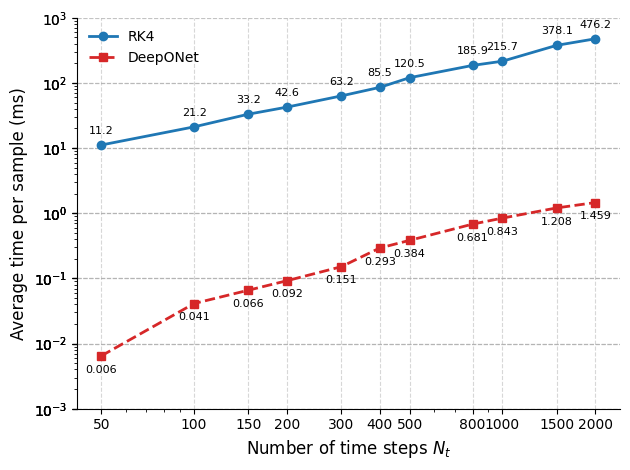


Line graph saved to DRE_3D/speed_vs_Nt.png

========== Results Summary ==========
Nt     RK4 (ms)     DeepONet (ms)   Speedup 
50     11.1564      0.0065          1723.53 
100    21.1989      0.0412          514.61  
150    33.1753      0.0659          503.16  
200    42.5587      0.0922          461.74  
300    63.2396      0.1511          418.55  
400    85.5411      0.2928          292.10  
500    120.4714     0.3839          313.83  
800    185.8788     0.6814          272.77  
1000   215.7102     0.8428          255.94  
1500   378.0858     1.2082          312.94  
2000   476.2033     1.4595          326.29  


In [18]:
import os
import time
import numpy as np
import torch
import math
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==============================
# Global parameters (consistent with training)
# ==============================
d = 3
m = 1
r_base = 5
T_end = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================
# Basis functions
# ==============================
def phi(i, t):
    return np.cos(i * np.pi * t)

# ==============================
# Flatten coefficients (only C, D, E, P_T)
# ==============================
def flatten_coeffs(C, D, E, P_T):
    c_vec = [ci.flatten() for ci in C]
    d_vec = [di.flatten() for di in D]
    e_vec = [ei.flatten() for ei in E]
    pT_vec = P_T.flatten()
    return np.concatenate(c_vec + d_vec + e_vec + [pT_vec])

# ==============================
# Recover coefficients from flattened vector
# ==============================
def unflatten_coeffs(vec):
    idx = 0
    C = [vec[idx:idx+d*d].reshape(d, d) for _ in range(r_base)]
    idx += r_base * d * d
    D = [vec[idx:idx+d*m].reshape(d, m) for _ in range(r_base)]
    idx += r_base * d * m
    E = [vec[idx:idx+d*d].reshape(d, d) for _ in range(r_base)]
    idx += r_base * d * d
    P_T = vec[idx:idx+d*d].reshape(d, d)
    return C, D, E, P_T

# ==============================
# Randomly generate a set of coefficients
# ==============================
def generate_random_coeffs():
    C = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]
    D = [np.random.randn(d, m) * 0.05 for _ in range(r_base)]
    E = [np.random.randn(d, d) * 0.05 for _ in range(r_base)]
    P_T = np.eye(d)
    return C, D, E, P_T

# ==============================
# Generate fixed test set (coefficient flattened vectors)
# ==============================
def generate_fixed_dataset(num_samples):
    branch_list = []
    for _ in range(num_samples):
        C, D, E, P_T = generate_random_coeffs()
        branch_list.append(flatten_coeffs(C, D, E, P_T))
    return np.stack(branch_list)  # (num_samples, branch_dim)

# ==============================
# DeepONet model definition (consistent with training)
# ==============================
class DeepONet(nn.Module):
    def __init__(self, branch_dim, out_dim, p=128):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(branch_dim, 256), nn.GELU(),
            nn.Linear(256, 256), nn.GELU(),
            nn.Linear(256, p)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, 128), nn.GELU(),
            nn.Linear(128, 128), nn.GELU(),
            nn.Linear(128, p)
        )
        self.fc = nn.Linear(p, out_dim)

    def forward(self, b_in, t_in):
        b = self.branch(b_in)
        t = self.trunk(t_in)
        if t.dim() == 3:
            b = b.unsqueeze(1)
        return self.fc(b * t)

# ==============================
# Load trained model
# ==============================
def load_trained_model(model_path):
    branch_dim = r_base*d*d + r_base*d*m + r_base*d*d + d*d
    out_dim = d*d
    model = DeepONet(branch_dim, out_dim).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Model loaded successfully: {model_path}")
    return model

# ==============================
# RK4 solution for Riccati (for a single system)
# ==============================
def solve_riccati_rk4(coeff_vec, t_grid):
    start = time.perf_counter()
    C, D, E, P_T = unflatten_coeffs(coeff_vec)
    R = np.eye(m)
    R_inv = np.linalg.inv(R)

    def A(t):
        return sum(C[i] * phi(i, t) for i in range(r_base))
    def B(t):
        return sum(D[i] * phi(i, t) for i in range(r_base))
    def Q(t):
        M = sum(E[i] * phi(i, t) for i in range(r_base))
        return M @ M.T

    def riccati_rhs(t, P):
        return -A(t).T @ P - P @ A(t) + P @ B(t) @ R_inv @ B(t).T @ P - Q(t)

    dt = t_grid[1] - t_grid[0]
    h = -dt
    P = P_T.copy()
    for k in range(len(t_grid)-2, -1, -1):
        tk = t_grid[k+1]
        k1 = riccati_rhs(tk, P)
        t_mid = tk + h/2
        P_mid = P + (h/2) * k1
        k2 = riccati_rhs(t_mid, P_mid)
        P_mid2 = P + (h/2) * k2
        k3 = riccati_rhs(t_mid, P_mid2)
        t_next = t_grid[k]
        P_end = P + h * k3
        k4 = riccati_rhs(t_next, P_end)
        P = P + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        P = (P + P.T) / 2
    elapsed = time.perf_counter() - start
    return elapsed

# ==============================
# DeepONet batch inference (forward pass for all samples at once)
# ==============================
def deeponet_batch_inference(model, branch_vectors, t_grid_torch):
    num_samples = branch_vectors.shape[0]
    branch_tensor = torch.tensor(branch_vectors, dtype=torch.float32).to(device)   # (num_samples, branch_dim)
    t_batch = t_grid_torch.unsqueeze(0).repeat(num_samples, 1, 1)                 # (num_samples, Nt, 1)
    # Warm-up
    with torch.no_grad():
        _ = model(branch_tensor[:min(10, num_samples)], t_batch[:min(10, num_samples)])

    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(branch_tensor, t_batch)   # (num_samples, Nt, d*d)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    avg_per_sample_ms = elapsed / num_samples * 1000
    return elapsed, avg_per_sample_ms

# ==============================
# Main program
# ==============================
if __name__ == "__main__":
    # 1. Load model
    model_path = "DRE_3D/DeepONet_model_d3_epochs50.pth"   # modify to actual path
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file does not exist: {model_path}")
    model = load_trained_model(model_path)

    # 2. Generate fixed test system set (shared across all Nt)
    NUM_SAMPLES = 100   # can be adjusted based on GPU memory; reduce to 50 if memory is insufficient
    print(f"Generating {NUM_SAMPLES} fixed random systems...")
    fixed_branch_vectors = generate_fixed_dataset(NUM_SAMPLES)   # (NUM_SAMPLES, branch_dim)

    # 3. Define list of time steps to test
    Nt_list = [50,100,150,200,300,400,500,800,1000,1500,2000]
    rk4_times = []      # average RK4 time per Nt (ms)
    donet_times = []    # average DeepONet time per Nt (ms)

    for Nt in Nt_list:
        print(f"\nTesting Nt = {Nt} ...")
        # Time grid
        t_grid_np = np.linspace(0, T_end, Nt)
        t_grid_torch = torch.linspace(0, T_end, Nt).view(-1, 1).to(device)

        # RK4 test (sample by sample)
        print("  Performing RK4 test...")
        rk4_sample_times = []
        for i in range(NUM_SAMPLES):
            t = solve_riccati_rk4(fixed_branch_vectors[i], t_grid_np)
            rk4_sample_times.append(t)
            if (i+1) % 20 == 0:
                print(f"    RK4 completed {i+1}/{NUM_SAMPLES} samples")
        rk4_avg = np.mean(rk4_sample_times) * 1000   # convert to ms
        rk4_times.append(rk4_avg)
        print(f"    RK4 average time: {rk4_avg:.4f} ms")

        # DeepONet batch test
        print("  Performing DeepONet batch test...")
        _, donet_avg = deeponet_batch_inference(model, fixed_branch_vectors, t_grid_torch)
        donet_times.append(donet_avg)
        print(f"    DeepONet average time: {donet_avg:.4f} ms")

    # 4. Plot line graph
    save_dir = "DRE_3D"
    # ---------- Color scheme (publication style) ----------
    color_rk4 = '#1f77b4'
    color_don = '#d62728'
    
    # ---------- Curves ----------
    plt.plot(Nt_list, rk4_times,
             marker='o', linestyle='-',
             color=color_rk4,
             linewidth=2, markersize=6,
             label='RK4')
    
    plt.plot(Nt_list, donet_times,
             marker='s', linestyle='--',
             color=color_don,
             linewidth=2, markersize=6,
             label='DeepONet')
    all_times = rk4_times + donet_times
    min_time = min(t for t in all_times if t > 0)
    max_time = max(all_times)
    
    plt.yscale('log')
    plt.xscale('log')
    plt.xticks(Nt_list, [str(nt) for nt in Nt_list])   # 仍显示所有标签，但位置按对数分布
    lower = 1e-3  # force start from 10^-3
    upper = 10 ** math.ceil(math.log10(max_time))
    plt.ylim(lower, upper)
    
    ax = plt.gca()
    
    # ---------- Major ticks and grid ----------
    ax.xaxis.set_major_locator(ticker.FixedLocator(Nt_list))
    # Logarithmic y-axis ticks: 10^-3, 10^-2, 10^-1, 10^0, ...
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1,0.1,0.01,0.001]))
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10.0))
    
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.grid(False, which='minor')  # remove minor grid lines
    plt.xlabel('Number of time steps $N_t$', fontsize=12)
    plt.ylabel('Average time per sample (ms)', fontsize=12)
    
    # ---------- Legend ----------
    plt.legend(fontsize=10, frameon=False)
    
    # ---------- Annotations (avoid overlap) ----------
    for x, y1, y2 in zip(Nt_list, rk4_times, donet_times):
        plt.annotate(f'{y1:.1f}', (x, y1),
                     textcoords="offset points",
                     xytext=(0, 8),
                     ha='center',
                     fontsize=8)
        plt.annotate(f'{y2:.3f}', (x, y2),
                     textcoords="offset points",
                     xytext=(0, -12),
                     ha='center',
                     fontsize=8)
    
    # ---------- Remove top and right spines ----------
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # ---------- Layout ----------
    plt.tight_layout()
    
    # ---------- Save ----------
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, "speed_vs_Nt.png"),
                dpi=200, bbox_inches='tight')
    
    plt.show()
    print(f"\nLine graph saved to {save_dir}/speed_vs_Nt.png")

    # Print results table
    print("\n========== Results Summary ==========")
    print(f"{'Nt':<6} {'RK4 (ms)':<12} {'DeepONet (ms)':<15} {'Speedup':<8}")
    for nt, rk, dn in zip(Nt_list, rk4_times, donet_times):
        speedup = rk / dn if dn > 0 else np.inf
        print(f"{nt:<6} {rk:<12.4f} {dn:<15.4f} {speedup:<8.2f}")
    print("=======================================")